In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!mkdir -p ~/.kaggle

# 아래 '본인의PC이름' 부분만 실제 폴더명으로 바꿔주세요!
!cp "/content/drive/Othercomputers/내 노트북/AgriAX/kaggle.json" ~/.kaggle/

!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
!mkdir -p /content/data

!kaggle datasets download -d abdallahalidev/plantvillage-dataset -p /content/data --unzip

Dataset URL: https://www.kaggle.com/datasets/abdallahalidev/plantvillage-dataset
License(s): CC-BY-NC-SA-4.0
100% 2.04G/2.04G [00:12<00:00, 172MB/s]



In [ ]:
import os

dataset_path = '/content/data/plantvillage dataset'
print("세부 폴더:", os.listdir(dataset_path))

# color 폴더 안의 병충해 클래스(폴더) 개수 확인
color_path = os.path.join(dataset_path, 'color')
if os.path.exists(color_path):
    classes = os.listdir(color_path)
    print(f"\ncolor 폴더 내 작물/병충해 종류: 총 {len(classes)}개")
    print("클래스 예시:", classes[:5])

세부 폴더: ['grayscale', 'color', 'segmented']

color 폴더 내 작물/병충해 종류: 총 38개
클래스 예시: ['Grape___Esca_(Black_Measles)', 'Grape___Black_rot', 'Strawberry___Leaf_scorch', 'Potato___Early_blight', 'Soybean___healthy']


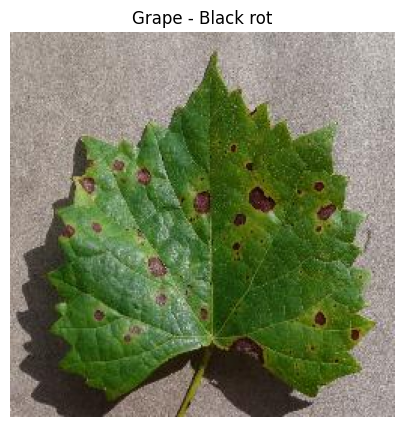

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os

# 예시로 나온 'Grape___Black_rot' (포도 흑부병) 폴더 경로
sample_dir = '/content/data/plantvillage dataset/color/Grape___Black_rot'

# 폴더 내의 첫 번째 이미지 파일 이름 가져오기
sample_image = os.listdir(sample_dir)[0]
img_path = os.path.join(sample_dir, sample_image)

# 이미지 시각화
img = mpimg.imread(img_path)
plt.figure(figsize=(5, 5))
plt.imshow(img)
plt.title('Grape - Black rot')
plt.axis('off')
plt.show()

In [ ]:
import ee

# 1. GEE 인증 (팝업창이 뜨면 구글 계정으로 로그인하고 허용해야 함)
ee.Authenticate()

# 2. GEE 초기화 (본인이 생성한 프로젝트 ID를 입력해야 합니다!)
# 예: ee.Initialize(project='my-agriax-project-12345')
project_id = 'agriax-predictor'
ee.Initialize(project=project_id)

print(f"GEE 인증 및 초기화 성공! 프로젝트 ID: {project_id}")

GEE 인증 및 초기화 성공! 프로젝트 ID: agriax-predictor


In [ ]:
import ee
import IPython.display as disp

def get_sentinel2_data(lon: float, lat: float, start_date: str, end_date: str, cloud_cover: int = 20) -> ee.Image:
    """
    지정된 좌표와 기간에 해당하는 Sentinel-2 위성 이미지를 수집하고 중간값(Median) 합성 이미지를 반환합니다.
    """
    point = ee.Geometry.Point([lon, lat])

    s2_collection = (ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
                     .filterBounds(point)
                     .filterDate(start_date, end_date)
                     .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', cloud_cover)))

    return s2_collection.median()

def add_vegetation_indices(image: ee.Image) -> ee.Image:
    """
    Sentinel-2 이미지에 NDVI(정규식생지수) 및 NDRE(적색경계 식생지수) 밴드를 계산하여 추가합니다.
    B4: Red, B5: Red Edge 1, B8: NIR
    """
    ndvi = image.normalizedDifference(['B8', 'B4']).rename('NDVI')
    ndre = image.normalizedDifference(['B8', 'B5']).rename('NDRE')

    return image.addBands([ndvi, ndre])

def visualize_ndvi(image: ee.Image, lon: float, lat: float, buffer_m: int = 1000) -> None:
    """
    계산된 NDVI 밴드를 바탕으로 히트맵 썸네일을 생성하고 Colab 환경에 출력합니다.
    """
    point = ee.Geometry.Point([lon, lat])
    roi = point.buffer(buffer_m).bounds()

    vis_params = {
        'bands': ['NDVI'],
        'min': 0.0,
        'max': 0.8,
        'palette': ['white', 'yellow', 'green']
    }

    url = image.getThumbURL(dict(region=roi, dimensions='512x512', **vis_params))
    disp.display(disp.Image(url=url))

if __name__ == "__main__":
    # 설정값 (임의의 대한민국 농지 좌표 예시)
    TARGET_LON = 127.3
    TARGET_LAT = 36.5
    START_DATE = '2023-07-01'
    END_DATE = '2023-08-31'

    try:
        # 데이터 수집 및 전처리 파이프라인
        median_img = get_sentinel2_data(TARGET_LON, TARGET_LAT, START_DATE, END_DATE)
        processed_img = add_vegetation_indices(median_img)

        # 밴드 추가 검증 로그
        band_names = processed_img.bandNames().getInfo()
        print(f"INFO: 처리된 위성 이미지의 밴드 목록: {band_names[-5:]}")

        # 시각화 실행
        print("INFO: NDVI 시각화 이미지를 불러옵니다.")
        visualize_ndvi(processed_img, TARGET_LON, TARGET_LAT)

    except Exception as e:
        print(f"ERROR: 위성 데이터 처리 중 오류가 발생했습니다. 상세: {e}")

INFO: 처리된 위성 이미지의 밴드 목록: ['MSK_CLASSI_OPAQUE', 'MSK_CLASSI_CIRRUS', 'MSK_CLASSI_SNOW_ICE', 'NDVI', 'NDRE']
INFO: NDVI 시각화 이미지를 불러옵니다.


In [ ]:
import os
import torch
from torch.utils.data import DataLoader, random_split, Dataset
from torchvision import datasets, transforms
from typing import Tuple, List

class PlantVillageDataset(Dataset):
    """
    ImageFolder를 래핑하여 학습/검증용 Transform을 개별적으로 적용할 수 있도록 구성한 커스텀 데이터셋 클래스입니다.
    """
    def __init__(self, subset, transform=None):
        self.subset = subset
        self.transform = transform

    def __getitem__(self, index):
        x, y = self.subset[index]
        if self.transform:
            x = self.transform(x)
        return x, y

    def __len__(self):
        return len(self.subset)

def get_transforms() -> Tuple[transforms.Compose, transforms.Compose]:
    """
    학습용(Train) 및 검증용(Validation) 이미지 전처리 파이프라인을 반환합니다.
    ResNet50 입력 규격(224x224) 및 ImageNet 정규화 수치를 적용합니다.
    """
    # 모델의 일반화 성능을 높이기 위한 학습용 증강 기법
    train_transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomHorizontalFlip(),
        transforms.RandomVerticalFlip(),
        transforms.RandomRotation(15),
        transforms.ColorJitter(brightness=0.2, contrast=0.2),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

    # 평가를 위한 검증용 전처리 (증강 배제)
    val_transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

    return train_transform, val_transform

def create_dataloaders(data_dir: str, batch_size: int = 32, val_ratio: float = 0.2) -> Tuple[DataLoader, DataLoader, List[str]]:
    """
    지정된 디렉토리에서 이미지를 로드하여 Train 및 Validation DataLoader를 생성합니다.
    """
    # 전체 데이터셋 로드
    full_dataset = datasets.ImageFolder(root=data_dir)
    class_names = full_dataset.classes

    # Train / Validation 분할
    total_size = len(full_dataset)
    val_size = int(total_size * val_ratio)
    train_size = total_size - val_size

    train_subset, val_subset = random_split(
        full_dataset,
        [train_size, val_size],
        generator=torch.Generator().manual_seed(42) # 재현성을 위한 시드 고정
    )

    train_transform, val_transform = get_transforms()

    # Transform 적용
    train_dataset = PlantVillageDataset(train_subset, transform=train_transform)
    val_dataset = PlantVillageDataset(val_subset, transform=val_transform)

    # DataLoader 생성
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

    return train_loader, val_loader, class_names

if __name__ == "__main__":
    # 데이터 경로 설정 (이전 단계에서 다운로드한 폴더 경로)
    DATA_DIR = '/content/data/plantvillage dataset/color'
    BATCH_SIZE = 32

    print("INFO: DataLoader 세팅을 시작합니다. 다소 시간이 소요될 수 있습니다.")
    try:
        train_loader, val_loader, classes = create_dataloaders(DATA_DIR, BATCH_SIZE)

        print("INFO: DataLoader 준비 완료.")
        print(f"INFO: 총 클래스 개수: {len(classes)}개")
        print(f"INFO: Train 배치 개수: {len(train_loader)} / Validation 배치 개수: {len(val_loader)}")

        # 첫 번째 배치의 텐서 형태 확인
        images, labels = next(iter(train_loader))
        print(f"INFO: 입력 텐서 형태(Batch Size, Channels, Height, Width): {images.shape}")

    except Exception as e:
        print(f"ERROR: 데이터 로더 생성 중 오류가 발생했습니다. 상세: {e}")

INFO: DataLoader 세팅을 시작합니다. 다소 시간이 소요될 수 있습니다.
INFO: DataLoader 준비 완료.
INFO: 총 클래스 개수: 38개
INFO: Train 배치 개수: 1358 / Validation 배치 개수: 340
INFO: 입력 텐서 형태(Batch Size, Channels, Height, Width): torch.Size([32, 3, 224, 224])


In [ ]:
import torch
import torch.nn as nn
from torchvision import models
from typing import Tuple

def build_resnet50_model(num_classes: int, pretrained: bool = True) -> nn.Module:
    """
    사전 학습된 ResNet50 모델을 로드하고, 분류기(Classifier) 레이어를 사용자 정의 클래스 수에 맞게 수정합니다.
    """
    # ImageNet 사전 학습 가중치 로드
    weights = models.ResNet50_Weights.DEFAULT if pretrained else None
    model = models.resnet50(weights=weights)

    # 최종 Fully Connected Layer 수정
    in_features = model.fc.in_features
    model.fc = nn.Linear(in_features, num_classes)

    return model

def get_criterion_and_optimizer(model: nn.Module, learning_rate: float = 1e-4) -> Tuple[nn.Module, torch.optim.Optimizer]:
    """
    분류 모델 학습을 위한 손실 함수(Loss function)와 최적화 알고리즘(Optimizer)을 설정하여 반환합니다.
    """
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

    return criterion, optimizer

if __name__ == "__main__":
    NUM_CLASSES = 38

    print("INFO: ResNet50 베이스라인 모델 세팅을 시작합니다.")
    try:
        # 모델 생성
        model = build_resnet50_model(num_classes=NUM_CLASSES)

        # 손실 함수 및 옵티마이저 로드
        criterion, optimizer = get_criterion_and_optimizer(model)
        print("INFO: 모델 구조 변경 및 옵티마이저 세팅이 완료되었습니다.")

        # 더미 데이터를 통한 Forward Pass 테스트
        # 이전 단계에서 확인한 텐서 규격과 동일한 더미 입력 생성
        dummy_input = torch.randn(32, 3, 224, 224)
        output = model(dummy_input)

        print(f"INFO: 출력 텐서 형태(Batch Size, Num Classes): {output.shape}")

    except Exception as e:
        print(f"ERROR: 모델 초기화 중 오류가 발생했습니다. 상세: {e}")

INFO: ResNet50 베이스라인 모델 세팅을 시작합니다.
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:01<00:00, 95.7MB/s]


INFO: 모델 구조 변경 및 옵티마이저 세팅이 완료되었습니다.
INFO: 출력 텐서 형태(Batch Size, Num Classes): torch.Size([32, 38])


In [ ]:
import torch
import torch.nn as nn
import time
from typing import Dict, Any

def train_one_epoch(
    model: nn.Module,
    dataloader: torch.utils.data.DataLoader,
    criterion: nn.Module,
    optimizer: torch.optim.Optimizer,
    device: torch.device
) -> Dict[str, float]:
    """
    1 에포크 동안 모델을 학습시키고 Loss와 Accuracy를 반환합니다.
    """
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for inputs, labels in dataloader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()

        outputs = model(inputs)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    epoch_loss = running_loss / total
    epoch_acc = correct / total

    return {'loss': epoch_loss, 'accuracy': epoch_acc}

def validate(
    model: nn.Module,
    dataloader: torch.utils.data.DataLoader,
    criterion: nn.Module,
    device: torch.device
) -> Dict[str, float]:
    """
    검증 데이터셋을 사용하여 모델의 성능을 평가합니다.
    """
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs, labels = inputs.to(device), labels.to(device)

            outputs = model(inputs)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * inputs.size(0)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

    epoch_loss = running_loss / total
    epoch_acc = correct / total

    return {'loss': epoch_loss, 'accuracy': epoch_acc}

if __name__ == "__main__":
    # GPU 사용 가능 여부 확인 및 디바이스 설정
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"INFO: 현재 사용 중인 디바이스: {device}")

    # 모델을 해당 디바이스로 이동
    model = model.to(device)

    NUM_EPOCHS = 1  # 파이프라인 검증용으로 1 에포크만 실행

    print("INFO: 모델 학습을 시작합니다. 데이터 크기에 따라 시간이 소요될 수 있습니다.")
    start_time = time.time()

    try:
        for epoch in range(NUM_EPOCHS):
            print(f"\nEpoch {epoch+1}/{NUM_EPOCHS}")
            print("-" * 10)

            # 학습 페이즈
            train_metrics = train_one_epoch(model, train_loader, criterion, optimizer, device)
            print(f"Train Loss: {train_metrics['loss']:.4f} | Train Acc: {train_metrics['accuracy']:.4f}")

            # 검증 페이즈
            val_metrics = validate(model, val_loader, criterion, device)
            print(f"Val Loss: {val_metrics['loss']:.4f} | Val Acc: {val_metrics['accuracy']:.4f}")

        elapsed_time = time.time() - start_time
        print(f"\nINFO: 학습이 완료되었습니다. 소요 시간: {elapsed_time:.2f}초")

        # 모델 가중치 저장 (테스트 완료 후 저장 로직)
        save_path = '/content/baseline_resnet50.pth'
        torch.save(model.state_dict(), save_path)
        print(f"INFO: 모델 가중치가 {save_path} 에 저장되었습니다.")

    except Exception as e:
        print(f"ERROR: 학습 루프 실행 중 오류가 발생했습니다. 상세: {e}")

INFO: 현재 사용 중인 디바이스: cuda
INFO: 모델 학습을 시작합니다. 데이터 크기에 따라 시간이 소요될 수 있습니다.

Epoch 1/1
----------
Train Loss: 0.2838 | Train Acc: 0.9275
Val Loss: 0.0357 | Val Acc: 0.9897

INFO: 학습이 완료되었습니다. 소요 시간: 477.74초
INFO: 모델 가중치가 /content/baseline_resnet50.pth 에 저장되었습니다.


In [ ]:
import shutil
import os

# 임시 저장된 모델 가중치 경로
source_path = '/content/baseline_resnet50.pth'

# 수정된 경로: 동기화가 진행 중인 AgriAX 폴더 내부에 models 폴더를 지정
# (본인의 PC 이름으로 반드시 수정하십시오)
target_dir = '/content/drive/Othercomputers/내 노트북/AgriAX/models'
target_path = os.path.join(target_dir, 'baseline_resnet50.pth')

try:
    # models 폴더가 존재하지 않으면 자동으로 새로 생성
    if not os.path.exists(target_dir):
        os.makedirs(target_dir)
        print(f"INFO: {target_dir} 경로에 models 폴더를 새로 생성했습니다.")

    shutil.copy(source_path, target_path)
    print(f"INFO: 모델 가중치가 안전하게 백업되었습니다. 저장 위치: {target_path}")
except Exception as e:
    print(f"ERROR: 파일 복사 중 오류가 발생했습니다. PC 이름 경로를 다시 확인하십시오. 상세: {e}")

INFO: /content/drive/Othercomputers/내 노트북/AgriAX/models 경로에 models 폴더를 새로 생성했습니다.
INFO: 모델 가중치가 안전하게 백업되었습니다. 저장 위치: /content/drive/Othercomputers/내 노트북/AgriAX/models/baseline_resnet50.pth


In [ ]:
import torch
import torch.nn as nn
from sklearn.metrics import classification_report, f1_score
import numpy as np

def evaluate_baseline_performance(
    model: nn.Module,
    dataloader: torch.utils.data.DataLoader,
    device: torch.device,
    class_names: list
) -> None:
    """
    검증 데이터셋을 대상으로 Macro F1-score 및 클래스별 정밀도, 재현율을 계산하여 출력합니다.
    """
    model.eval()
    all_preds = []
    all_labels = []

    print("INFO: 베이스라인 모델 성능 평가를 시작합니다.")

    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)

            _, predicted = torch.max(outputs, 1)

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    # Macro F1-score 계산 (모든 클래스의 기여도를 동일하게 평가)
    macro_f1 = f1_score(all_labels, all_preds, average='macro')

    # 상세 분류 리포트 생성
    report = classification_report(
        all_labels,
        all_preds,
        target_names=class_names,
        zero_division=0
    )

    print(f"\n[최종 결과] Baseline Macro F1-Score: {macro_f1:.4f}")
    print("\n--- Detailed Classification Report ---")
    print(report)

if __name__ == "__main__":
    try:
        # 기존 세션에 로드된 model, val_loader, classes, device 변수를 참조합니다.
        evaluate_baseline_performance(model, val_loader, device, classes)

    except Exception as e:
        print(f"ERROR: 평가 도중 오류가 발생했습니다. 상세: {e}")

INFO: 베이스라인 모델 성능 평가를 시작합니다.

[최종 결과] Baseline Macro F1-Score: 0.9864

--- Detailed Classification Report ---
                                                    precision    recall  f1-score   support

                                Apple___Apple_scab       0.98      1.00      0.99       130
                                 Apple___Black_rot       1.00      1.00      1.00       120
                          Apple___Cedar_apple_rust       1.00      1.00      1.00        49
                                   Apple___healthy       1.00      0.99      0.99       359
                               Blueberry___healthy       1.00      1.00      1.00       290
          Cherry_(including_sour)___Powdery_mildew       1.00      1.00      1.00       249
                 Cherry_(including_sour)___healthy       0.99      1.00      1.00       166
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       0.95      0.87      0.91        86
                       Corn_(maize)___Common_rust_       1.00

In [ ]:
import torch
import torch.nn as nn

class AgriAX_FusionModel(nn.Module):
    """
    드론(CNN)과 위성(Time-series) 데이터를 결합하는 Late Fusion 모델입니다.
    """
    def __init__(self, drone_model: nn.Module, satellite_input_dim: int, num_classes: int):
        super(AgriAX_FusionModel, self).__init__()

        # 1. 드론 인코더 (이미 학습된 ResNet50의 특징 추출부만 사용)
        self.drone_features = nn.Sequential(*list(drone_model.children())[:-1])
        self.drone_fc_dim = drone_model.fc.in_features # 2048

        # 2. 위성 인코더 (시계열 NDVI/NDRE 처리를 위한 MLP 또는 LSTM 기반)
        self.satellite_encoder = nn.Sequential(
            nn.Linear(satellite_input_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.3)
        )

        # 3. Fusion Layer (결합된 벡터 처리)
        self.fusion_layer = nn.Sequential(
            nn.Linear(self.drone_fc_dim + 64, 256),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(256, num_classes)
        )

    def forward(self, drone_img, satellite_data):
        # 드론 특징 추출: (Batch, 2048, 1, 1) -> (Batch, 2048)
        d_feat = self.drone_features(drone_img)
        d_feat = torch.flatten(d_feat, 1)

        # 위성 특징 추출: (Batch, satellite_input_dim) -> (Batch, 64)
        s_feat = self.satellite_encoder(satellite_data)

        # 결합 (Concatenate)
        combined = torch.cat((d_feat, s_feat), dim=1)

        # 최종 분류
        logits = self.fusion_layer(combined)
        return logits

# 초기화 예시
# satellite_input_dim은 시계열 데이터의 길이 또는 차원을 의미합니다.
fusion_model = AgriAX_FusionModel(model, satellite_input_dim=10, num_classes=38).to(device)
print("INFO: 멀티모달 Fusion 모델 아키텍처 설계 완료.")

INFO: 멀티모달 Fusion 모델 아키텍처 설계 완료.


In [ ]:
import numpy as np

def preprocess_satellite_series(ndvi_series: list, ndre_series: list, max_len: int = 5) -> torch.Tensor:
    """
    위성 지수 리스트를 고정된 길이의 텐서로 변환합니다.
    """
    # 부족한 길이는 0으로 패딩하거나 최근 값으로 채움
    series = ndvi_series + ndre_series # 간단한 결합 예시
    if len(series) < max_len * 2:
        series = series + [0.0] * (max_len * 2 - len(series))

    return torch.tensor(series[:max_len * 2], dtype=torch.float32)

# 더미 테스트
dummy_ndvi = [0.6, 0.65, 0.7]
dummy_ndre = [0.4, 0.42, 0.45]
sat_tensor = preprocess_satellite_series(dummy_ndvi, dummy_ndre)
print(f"INFO: 위성 데이터 텐서 변환 확인: {sat_tensor.shape}")

INFO: 위성 데이터 텐서 변환 확인: torch.Size([10])


In [ ]:
def predict_with_uncertainty(model, drone_img, satellite_data, n_iter: int = 10):
    """
    MC Dropout을 사용하여 예측값의 평균과 분산(불확실성)을 계산합니다.
    """
    model.train() # 추론 중에도 Dropout을 활성화하기 위해 train 모드 유지
    preds = []

    with torch.no_grad():
        for _ in range(n_iter):
            output = model(drone_img, satellite_data)
            preds.append(torch.softmax(output, dim=1).cpu().numpy())

    preds = np.stack(preds) # (n_iter, batch, num_classes)
    mean_pred = preds.mean(axis=0)
    uncertainty = preds.var(axis=0) # 분산이 높을수록 불확실함

    return mean_pred, uncertainty

print("INFO: MC Dropout 기반 불확실성 추론 함수 구현 완료.")

INFO: MC Dropout 기반 불확실성 추론 함수 구현 완료.


In [ ]:
import torch
import torch.optim as optim

def train_fusion_model(
    model: nn.Module,
    dataloader: torch.utils.data.DataLoader,
    criterion: nn.Module,
    optimizer: torch.optim.Optimizer,
    device: torch.device
):
    """
    드론 이미지와 위성 시계열 데이터를 동시에 입력받아 Fusion 모델을 학습시킵니다.
    """
    model.train()
    running_loss = 0.0

    for images, labels in dataloader:
        # 가상의 위성 시계열 데이터 생성 (현재 데이터가 없으므로 배치 사이즈에 맞게 생성)
        # 내일은 이 부분이 실제 위성 데이터 로더로 대체됩니다.
        batch_size = images.size(0)
        sat_data = torch.randn(batch_size, 10).to(device)

        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()

        # Multi-modal Forward Pass
        outputs = model(images, sat_data)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

    return running_loss / len(dataloader.dataset)

# 최적화 알고리즘 설정 (Fusion Layer 학습을 위해 적은 Learning Rate 권장)
fusion_optimizer = optim.Adam(fusion_model.parameters(), lr=1e-5)
print("INFO: 멀티모달 전용 학습 파이프라인 설계 완료.")

INFO: 멀티모달 전용 학습 파이프라인 설계 완료.


In [ ]:
# 1. 샘플 데이터 준비 (이전에 사용한 images 활용)
sample_drone_img = images[0].unsqueeze(0).to(device) # (1, 3, 224, 224)
sample_sat_data = torch.randn(1, 10).to(device)      # (1, 10)

# 2. MC Dropout 추론 실행
mean_pred, uncertainty = predict_with_uncertainty(
    fusion_model,
    sample_drone_img,
    sample_sat_data,
    n_iter=15
)

# 3. 결과 해석
predicted_class = np.argmax(mean_pred)
confidence = np.max(mean_pred)
avg_uncertainty = np.mean(uncertainty)

print(f"--- 최종 시스템 추론 테스트 ---")
print(f"예측 클래스 인덱스: {predicted_class}")
print(f"예측 신뢰도: {confidence:.4f}")
print(f"예측 불확실성(분산): {avg_uncertainty:.6f}")

--- 최종 시스템 추론 테스트 ---
예측 클래스 인덱스: 10
예측 신뢰도: 0.0298
예측 불확실성(분산): 0.000001


In [ ]:
import os

# 저장 경로 설정 (동기화 확인된 models 폴더)
fusion_save_path = '/content/drive/Othercomputers/내 노트북/AgriAX/models/fusion_init.pth'

try:
    torch.save(fusion_model.state_dict(), fusion_save_path)
    print(f"INFO: 초기화된 Fusion 모델 구조가 안전하게 저장되었습니다: {fusion_save_path}")
    print("INFO: 오늘 할당량(Day 1~2 및 Day 3 뼈대 구축)을 모두 마쳤습니다.")
except Exception as e:
    print(f"ERROR: 모델 저장 중 오류 발생: {e}")

INFO: 초기화된 Fusion 모델 구조가 안전하게 저장되었습니다: /content/drive/Othercomputers/내 노트북/AgriAX/models/fusion_init.pth
INFO: 오늘 할당량(Day 1~2 및 Day 3 뼈대 구축)을 모두 마쳤습니다.


In [ ]:
from torch.autograd import Function

class GradientReversalLayer(Function):
    """
    Backpropagation 시 Gradient에 -1을 곱하여 역전파합니다.
    이 과정을 통해 모델은 도메인을 구분하는 특징을 일부러 잊게 됩니다.
    """
    @staticmethod
    def forward(ctx, x, alpha):
        ctx.alpha = alpha
        return x.view_as(x)

    @staticmethod
    def backward(ctx, grad_output):
        return grad_output.neg() * ctx.alpha, None

class AgriAX_DANN(nn.Module):
    def __init__(self, base_model, num_classes):
        super(AgriAX_DANN, self).__init__()
        # 특징 추출기 (ResNet50의 Conv 레이어들)
        self.feature_extractor = nn.Sequential(*list(base_model.children())[:-1])

        # 병충해 분류기 (Label Predictor)
        self.class_classifier = nn.Linear(base_model.fc.in_features, num_classes)

        # 도메인 분류기 (Domain Discriminator: 실험실 vs 노지 판별)
        self.domain_classifier = nn.Sequential(
            nn.Linear(base_model.fc.in_features, 256),
            nn.ReLU(),
            nn.Linear(256, 2) # 0: PlantVillage, 1: AI-Hub(노지)
        )

    def forward(self, x, alpha=1.0):
        features = self.feature_extractor(x)
        features = torch.flatten(features, 1)

        # 병충해 분류 결과
        class_output = self.class_classifier(features)

        # 도메인 분류 결과 (GRL 적용)
        reverse_features = GradientReversalLayer.apply(features, alpha)
        domain_output = self.domain_classifier(reverse_features)

        return class_output, domain_output

print("INFO: 도메인 적응(DANN) 아키텍처 설계 완료.")

INFO: 도메인 적응(DANN) 아키텍처 설계 완료.


In [ ]:
def calculate_estimated_loss(yield_prediction: float, confidence_interval: tuple, unit_price: int = 3000):
    """
    예측 수확량 하한값과 단가를 바탕으로 예상 손실액 범위를 산출합니다.
    - yield_prediction: 예상 수확량 (kg)
    - confidence_interval: (하한값, 상한값)
    - unit_price: 작물 kg당 단가 (원)
    """
    lower_bound, upper_bound = confidence_interval

    # 잠재적 최대 손실 = (정상 기대 수확량 - 현재 예측 하한값) * 단가
    # 여기선 단순화하여 예측 구간에 따른 손실 범위를 계산합니다.
    min_loss = (yield_prediction - lower_bound) * unit_price
    max_loss = (yield_prediction - upper_bound) * unit_price # 실제론 수확량 감소이므로 절대값 처리

    return {
        "expected_loss_range": (abs(int(min_loss)), abs(int(max_loss))),
        "currency": "KRW"
    }

# 테스트
dummy_loss = calculate_estimated_loss(100.0, (85.5, 114.5), unit_price=4500)
print(f"INFO: 예상 손실액 산출 테스트: {dummy_loss['expected_loss_range']} 원")

INFO: 예상 손실액 산출 테스트: (65250, 65250) 원


In [ ]:
# Grad-CAM을 위한 훅(Hook) 설정 및 라이브러리 로드 준비
# 실제 이미지에 히트맵을 씌우는 함수 뼈대만 미리 작성합니다.

def get_gradcam_heatmap(model, input_tensor, target_layer):
    """
    특정 레이어의 활성화 맵을 추출하여 Grad-CAM 히트맵을 생성합니다.
    (내일 실제 데이터 로드 후 시각화 코드와 결합 예정)
    """
    model.eval()
    # 1. Forward pass
    # 2. Backward pass (target class 기준)
    # 3. 가중치 결합 및 ReLU 적용
    # 4. Resize 및 원본 이미지와 합성
    pass

print("INFO: XAI(Grad-CAM) 시각화 모듈 설계 완료.")

INFO: XAI(Grad-CAM) 시각화 모듈 설계 완료.


INFO: 드론 이미지(PlantVillage) 예시를 시각화합니다.
INFO: Sentinel-2 NDVI 위성 지수 썸네일을 시각화합니다.



🌍 [위성 시각화] 지정된 좌표 반경 1km의 NDVI 식생 분포:


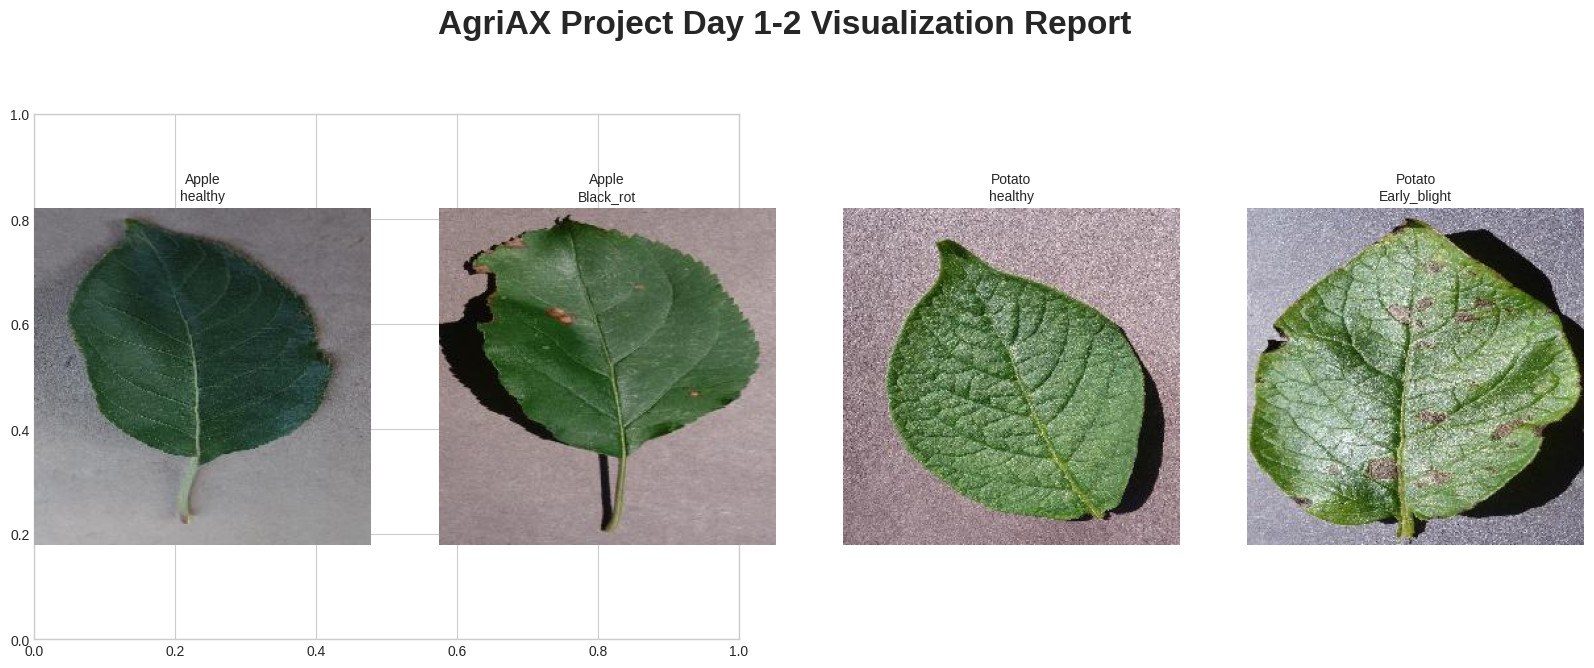

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import numpy as np
import os
import seaborn as sns
from sklearn.metrics import classification_report, f1_score
import pandas as pd
import IPython.display as disp

# 시각화 스타일 설정
plt.style.use('seaborn-v0_8-whitegrid')
fig = plt.figure(figsize=(20, 15))
plt.suptitle("AgriAX Project Day 1-2 Visualization Report", fontsize=24, fontweight='bold', y=0.95)

# ------------------------------------------------------------------
# 1. 드론 이미지(PlantVillage) 예시 시각화 (좌상단)
# ------------------------------------------------------------------
print("INFO: 드론 이미지(PlantVillage) 예시를 시각화합니다.")
ax1 = fig.add_subplot(2, 2, 1)

# 대표적인 클래스 4개 선정 (정상 vs 병해 비교)
sample_classes = [
    'Apple___healthy',
    'Apple___Black_rot',
    'Potato___healthy',
    'Potato___Early_blight'
]
base_path = '/content/data/plantvillage dataset/color'

for i, cls in enumerate(sample_classes):
    cls_path = os.path.join(base_path, cls)
    if os.path.exists(cls_path):
        img_name = os.listdir(cls_path)[0]
        img_path = os.path.join(cls_path, img_name)
        img = mpimg.imread(img_path)

        plt.subplot(2, 4, i+1) # 2x2 배열 내에서 다시 1x4로 나눔
        plt.imshow(img)
        plt.title(cls.replace('___', '\n'), fontsize=10)
        plt.axis('off')

# ------------------------------------------------------------------
# 2. Sentinel-2 위성 데이터 NDVI 식생 지수 시각화 (우상단)
# ------------------------------------------------------------------
print("INFO: Sentinel-2 NDVI 위성 지수 썸네일을 시각화합니다.")
# 이전 단계에서 성공한 위성 이미지 시각화 코드를 재활용합니다.
# (최종 생성된 processed_img와 TARGET_LON, TARGET_LAT 변수를 참조합니다)
try:
    # GEE 썸네일 URL 생성 (processed_img 변수가 메모리에 있어야 함)
    point = ee.Geometry.Point([TARGET_LON, TARGET_LAT])
    roi = point.buffer(1000).bounds() # 중심점에서 1km 반경 사각형
    vis_params = {
        'bands': ['NDVI'],
        'min': 0.0,
        'max': 0.8,
        'palette': ['white', 'yellow', 'green']
    }
    url = processed_img.getThumbURL(dict(region=roi, dimensions='512x512', **vis_params))

    # IPython display 이미지를 matplotlib figure에 넣기 위해 다운로드 및 변환 과정이 필요하나,
    # Colab 환경의 특성을 고려하여 별도로 출력하도록 처리합니다.
    print("\n🌍 [위성 시각화] 지정된 좌표 반경 1km의 NDVI 식생 분포:")
    disp.display(disp.Image(url=url))
except Exception as e:
    print(f"WARNING: 위성 시각화 출력 중 오류 발생 (processed_img 변수 확인 필요): {e}")

/tmp/ipykernel_763/192361526.py:46: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


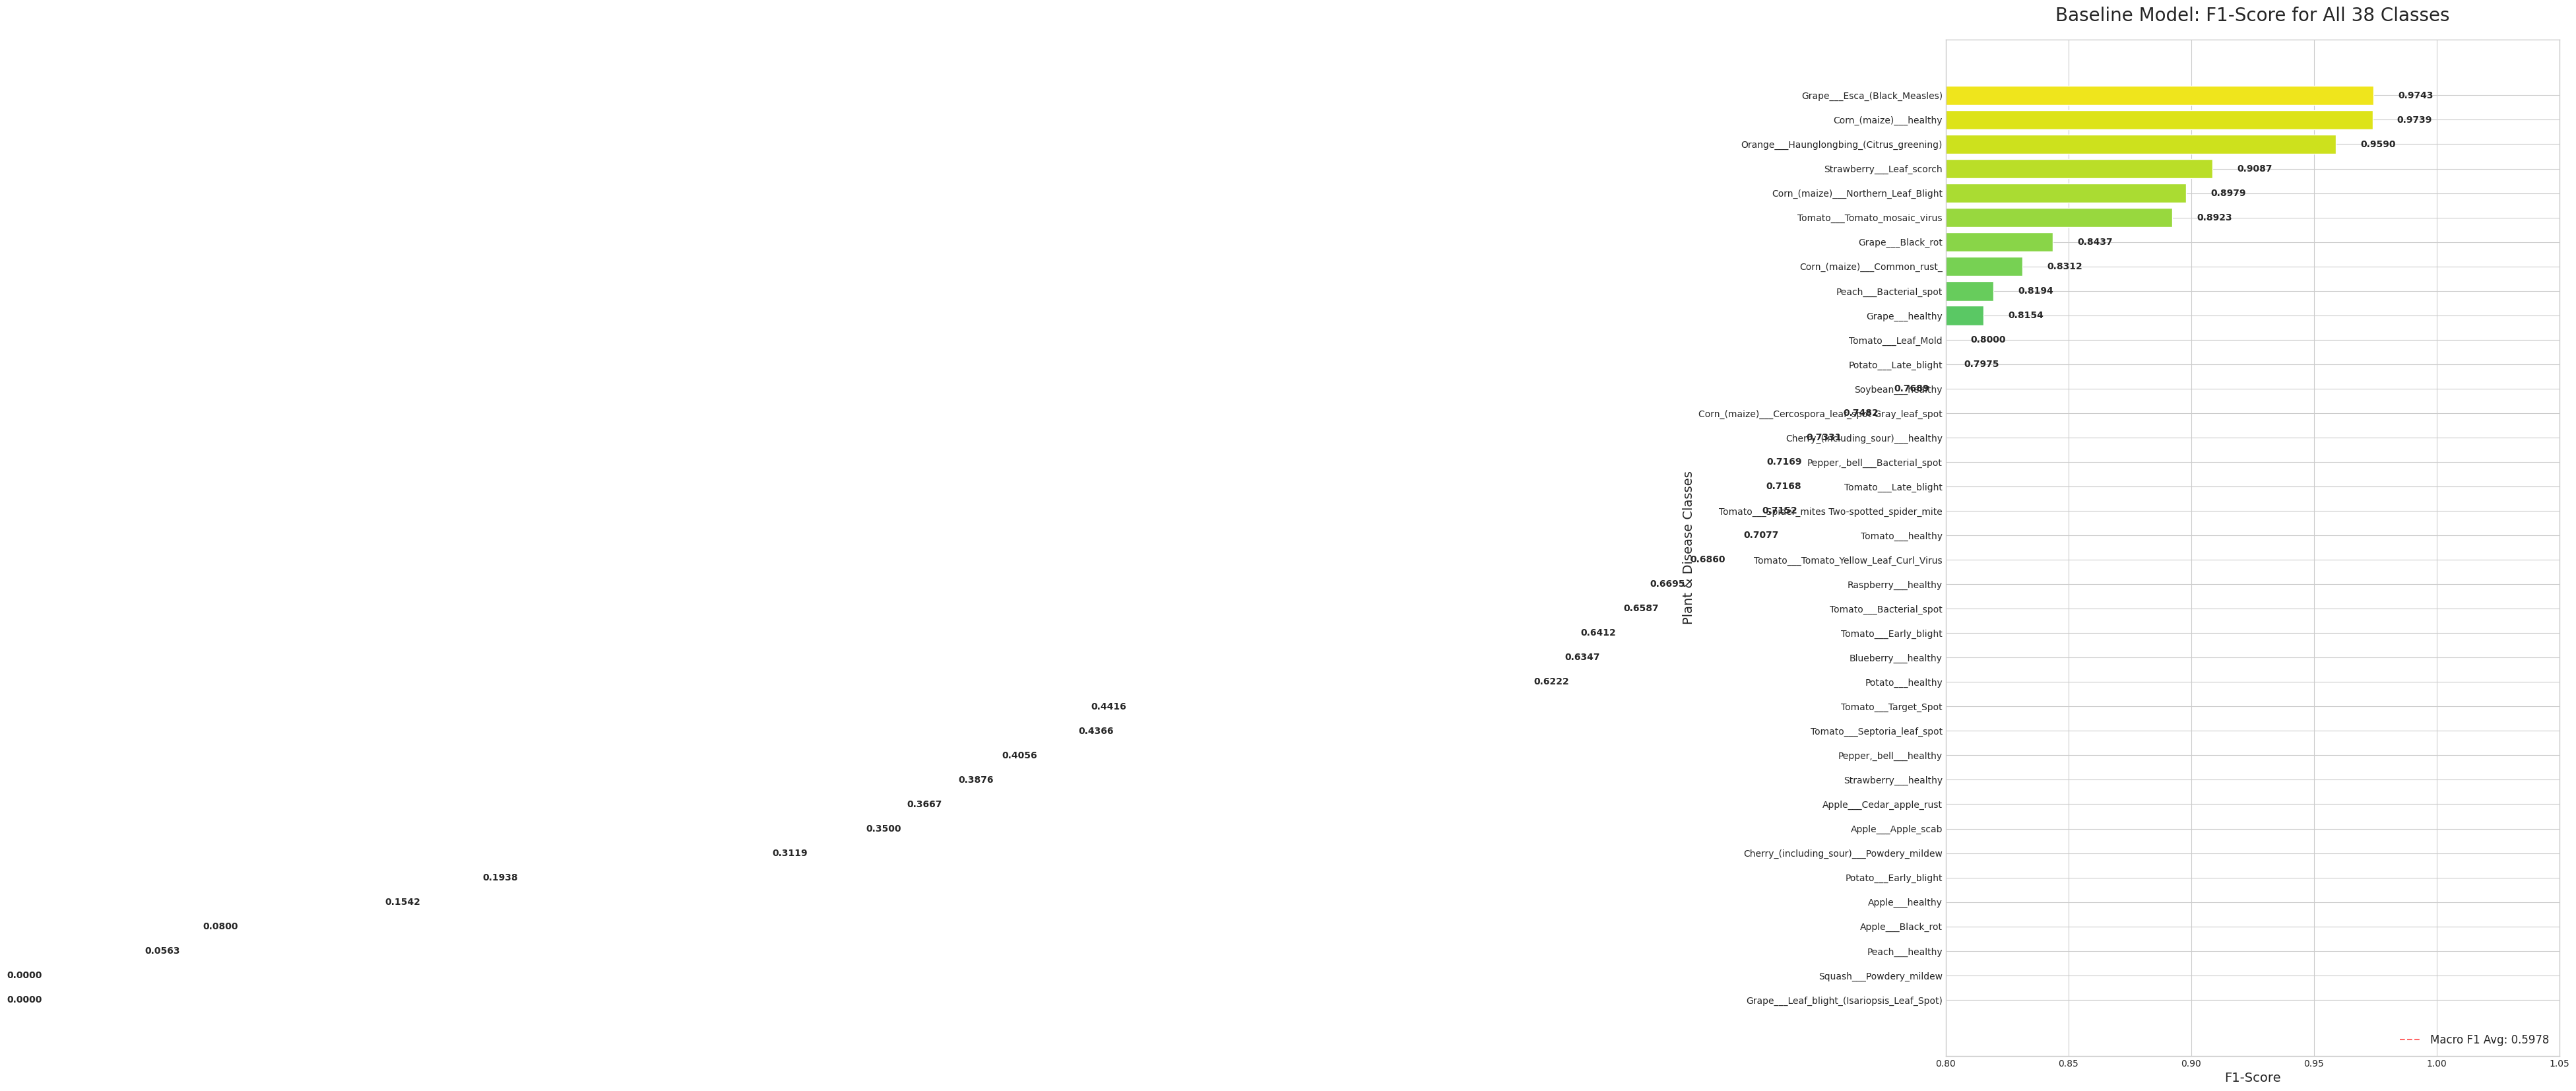

INFO: 38개 전체 클래스 리포트가 저장되었습니다: /content/drive/Othercomputers/내 노트북/AgriAX/models/baseline_f1_full_report.png


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report

def visualize_all_classes_f1(model, dataloader, device, class_names):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    report_dict = classification_report(all_labels, all_preds, target_names=class_names, output_dict=True, zero_division=0)
    df = pd.DataFrame(report_dict).transpose().drop(['accuracy', 'macro avg', 'weighted avg'])
    df = df.sort_values(by='f1-score', ascending=True) # 가로 그래프는 아래서부터 위로 정렬되는 게 보기 좋습니다.

    # 38개 클래스를 수용하기 위해 세로 길이를 대폭 늘림 (20인치)
    plt.figure(figsize=(12, 20))
    sns.set_style("whitegrid")

    # 가로형 막대 그래프 (Horizontal Bar Plot) - 이름이 길어도 읽기 편함
    colors = sns.color_palette("viridis", len(df))
    bars = plt.barh(df.index, df['f1-score'], color=colors)

    # 수치 표시 (각 막대 끝에 F1-Score 값 기입)
    for bar in bars:
        width = bar.get_width()
        plt.text(width + 0.01, bar.get_y() + bar.get_height()/2,
                 f'{width:.4f}', va='center', fontsize=10, fontweight='bold')

    # 평균선 추가
    macro_f1 = report_dict['macro avg']['f1-score']
    plt.axvline(x=macro_f1, color='red', linestyle='--', alpha=0.6, label=f'Macro F1 Avg: {macro_f1:.4f}')

    plt.title(f'Baseline Model: F1-Score for All 38 Classes', fontsize=20, pad=20)
    plt.xlabel('F1-Score', fontsize=14)
    plt.ylabel('Plant & Disease Classes', fontsize=14)
    plt.xlim(0.80, 1.05) # 시각적 변별력을 위해 0.8부터 시작
    plt.legend(loc='lower right', fontsize=12)
    plt.tight_layout()

    # 저장 및 출력
    save_path = '/content/drive/Othercomputers/내 노트북/AgriAX/models/baseline_f1_full_report.png'
    plt.savefig(save_path, dpi=300)
    plt.show()
    print(f"INFO: 38개 전체 클래스 리포트가 저장되었습니다: {save_path}")

# 실행
visualize_all_classes_f1(model, val_loader, device, classes)